# 09 — Finite-distance array analysis

Replace the plane-wave approximation with exact source-to-sensor distances.
The primary analyses are (1) a fixed-source SLC-40 speed search and (2) a
source-oriented range/cross-range profile that exposes the weak along-range
constraint of this small, distant array. Local Cartesian point-location remains
disabled because its edge-seeking solutions are not uniquely constrained.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from pyproj import Transformer
from obspy import read
from scipy.optimize import least_squares

project_root = Path.cwd().resolve()
if project_root.name == "notebooks2":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

PLANAR_ROOT = config.OUTPUT_DIR / "array_analysis_planar_refined"
PREPARATION_ROOT = config.OUTPUT_DIR / "candidate_airwave_preparation"
ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"

OUTPUT_ROOT = config.OUTPUT_DIR / "array_analysis_circular"
FIGURE_DIR = OUTPUT_ROOT / "event_figures"
SURFACE_DIR = OUTPUT_ROOT / "surfaces"
COMPOSITE_DIR = OUTPUT_ROOT / "composites"

for directory in (
    OUTPUT_ROOT,
    FIGURE_DIR,
    SURFACE_DIR,
    COMPOSITE_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

PLANAR_RESULTS_FILE = PLANAR_ROOT / "planar_array_results.csv"
EVENT_FILTER_FILE = PLANAR_ROOT / "event_filter_decisions.csv"
EVENT_STREAM_DIR = PREPARATION_ROOT / "event_streams"

CHANNELS = ("DD1", "DD2", "DD3")
REFERENCE_CHANNEL = "DD2"
PRINCIPAL_EXPLOSION_EVENT_NUMBER = 13

SCORE_WEIGHT_SEMBLANCE = 0.60

# Fixed-source speed search.
SPEED_MIN_MPS = 280.0
SPEED_MAX_MPS = 440.0
SPEED_STEP_MPS = 0.5

# Constrained local source search. This speed is not optimized simultaneously.
LOCAL_GRID_SPEED_MPS = 352.0
LOCAL_COARSE_HALF_WIDTH_M = 100.0
LOCAL_COARSE_STEP_M = 5.0
LOCAL_FINE_HALF_WIDTH_M = 12.0
LOCAL_FINE_STEP_M = 1.0

# Descriptive near-maximum widths, not formal confidence regions.
SURFACE_SCORE_DROPS = (0.01, 0.02)

RUN_LOCAL_SOURCE_GRID = False  # Legacy Cartesian point-location experiment; retained but disabled.
MAKE_EVENT_FIGURES = False     # Superseded by range-profile figures below.
SAVE_EVENT_SURFACES = True
MAX_EVENTS: int | None = None

# Preferred constraint analysis in source-oriented coordinates. Along-range is
# intentionally much broader than cross-range so an open range ridge is visible.
RUN_RANGE_PROFILE_ANALYSIS = True
ALONG_RANGE_HALF_WIDTH_M = 500.0
ALONG_RANGE_STEP_M = 20.0
CROSS_RANGE_HALF_WIDTH_M = 150.0
CROSS_RANGE_STEP_M = 5.0
MAKE_PROFILE_EVENT_FIGURES = True

# Optional explicit source coordinate. When None, reconstruct SLC-40 from the
# source-to-sensor distances stored in bchh_geometry.csv.
SLC40_EAST_M_OVERRIDE: float | None = None
SLC40_NORTH_M_OVERRIDE: float | None = None
SOURCE_ELEVATION_M = 0.0

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Load the planar catalogue and surveyed geometry

Notebook 08 remains the event-selection authority. This notebook analyzes the
same events and scoring windows, ensuring that changes in coherence arise from
the propagation model rather than different event definitions.

The nominal launch-pad coordinate is reconstructed by fitting a common horizontal
source point to the three tabulated source-to-sensor distances. The residuals are
exported and should be checked before interpreting metre-scale source offsets.


In [2]:
if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(ANALYSIS_CONFIG_FILE)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()

for required in (PLANAR_RESULTS_FILE, GEOMETRY_FILE):
    if not required.exists():
        raise FileNotFoundError(required)

planar = (
    pd.read_csv(PLANAR_RESULTS_FILE)
    .sort_values("event_number")
    .reset_index(drop=True)
)
if MAX_EVENTS is not None:
    planar = planar.head(MAX_EVENTS).copy()

geometry = pd.read_csv(GEOMETRY_FILE)
geometry["channel"] = geometry["channel"].astype(str).str.upper()

sensor_geometry = (
    geometry.loc[geometry["channel"].isin(CHANNELS)]
    .copy()
    .set_index("channel")
    .loc[list(CHANNELS)]
)

east_column = next(
    c for c in ("easting_m", "easting", "x_m")
    if c in sensor_geometry.columns
)
north_column = next(
    c for c in ("northing_m", "northing", "y_m")
    if c in sensor_geometry.columns
)
elevation_column = next(
    (
        c
        for c in ("elevation_m", "elevation", "z_m")
        if c in sensor_geometry.columns
    ),
    None,
)

sensor_xyz = np.column_stack([
    sensor_geometry[east_column].to_numpy(float),
    sensor_geometry[north_column].to_numpy(float),
    (
        sensor_geometry[elevation_column].to_numpy(float)
        if elevation_column
        else np.zeros(len(CHANNELS))
    ),
])

slc40_config = analysis_config["slc40"]

if SLC40_EAST_M_OVERRIDE is not None and SLC40_NORTH_M_OVERRIDE is not None:
    slc40_xy = np.array(
        [SLC40_EAST_M_OVERRIDE, SLC40_NORTH_M_OVERRIDE],
        dtype=float,
    )
    source_coordinate_method = "explicit projected override"
else:
    transformer = Transformer.from_crs(
        "EPSG:4326",
        "EPSG:32617",
        always_xy=True,
    )
    source_east_m, source_north_m = transformer.transform(
        float(slc40_config["longitude"]),
        float(slc40_config["latitude"]),
    )
    slc40_xy = np.array(
        [source_east_m, source_north_m],
        dtype=float,
    )
    source_coordinate_method = "canonical SLC-40 latitude/longitude"

slc40_xyz = np.array(
    [slc40_xy[0], slc40_xy[1], SOURCE_ELEVATION_M],
    dtype=float,
)

reported_distances_m = (
    sensor_geometry["distance_m"].to_numpy(float)
    if "distance_m" in sensor_geometry.columns
    else np.full(len(CHANNELS), np.nan)
)
canonical_distances_m = np.linalg.norm(
    sensor_xyz - slc40_xyz,
    axis=1,
)
source_fit_residuals_m = (
    canonical_distances_m - reported_distances_m
)

array_centroid_xyz = sensor_xyz.mean(axis=0)
source_vector = slc40_xyz[:2] - array_centroid_xyz[:2]
slc40_range_m = float(np.linalg.norm(source_vector))
slc40_back_azimuth_deg = float(
    np.degrees(
        np.arctan2(source_vector[0], source_vector[1])
    )
    % 360.0
)

geometry_audit = pd.DataFrame({
    "channel": CHANNELS,
    "east_m": sensor_xyz[:, 0],
    "north_m": sensor_xyz[:, 1],
    "elevation_m": sensor_xyz[:, 2],
    "reported_distance_m": sensor_geometry.get(
        "distance_m",
        pd.Series(np.nan, index=sensor_geometry.index),
    ).to_numpy(float),
    "fitted_distance_m": np.linalg.norm(
        sensor_xyz - slc40_xyz,
        axis=1,
    ),
    "distance_fit_residual_m": source_fit_residuals_m,
})
geometry_audit.to_csv(
    OUTPUT_ROOT / "circular_geometry_audit.csv",
    index=False,
)

print(f"Planar results: {PLANAR_RESULTS_FILE}")
print(f"Geometry: {GEOMETRY_FILE}")
print(f"Events inherited from Notebook 08: {len(planar)}")
print(
    f"SLC-40 ({source_coordinate_method}): "
    f"E={slc40_xyz[0]:.3f} m, "
    f"N={slc40_xyz[1]:.3f} m"
)
print(
    f"Centroid-to-source range={slc40_range_m:.2f} m; "
    f"back azimuth={slc40_back_azimuth_deg:.3f}°"
)
display(geometry_audit)


Planar results: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/array_analysis_planar_refined/planar_array_results.csv
Geometry: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/02_bchh_channels.csv
Events inherited from Notebook 08: 138
SLC-40 (canonical SLC-40 latitude/longitude): E=541352.817 m, N=3159526.382 m
Centroid-to-source range=1419.79 m; back azimuth=199.025°


,channel,east_m,north_m,elevation_m,reported_distance_m,fitted_distance_m,distance_fit_residual_m
0,DD1,541816.300901,3.160889e+06,0.0,1439.963831,1439.418575,-0.545255
1,DD2,541828.276924,3.160851e+06,0.0,1408.338457,1407.805185,-0.533272
2,DD3,541802.343163,3.160865e+06,0.0,1412.854330,1412.319330,-0.535000


## Coherence and exact-distance helpers

For a trial source position \(\mathbf{x}_s\) and speed \(c\), the receiver delay
relative to DD2 is

\[
\Delta t_i=\frac{\lVert\mathbf{x}_i-\mathbf{x}_s\rVert-
\lVert\mathbf{x}_{DD2}-\mathbf{x}_s\rVert}{c}.
\]

The same normalized three-channel coherence statistic and event scoring windows
used in Notebook 08 are retained.


In [3]:
def unique_trace(stream, channel):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one {channel}; found {len(matches)}")
    return matches[0]


def interpolate_trace_epoch(trace, epoch_s):
    start = float(trace.stats.starttime.timestamp)
    rate = float(trace.stats.sampling_rate)
    source_epoch = start + np.arange(trace.stats.npts, dtype=float) / rate
    return np.interp(epoch_s, source_epoch, np.asarray(trace.data, float), left=np.nan, right=np.nan)


def delays_for_source(source_xyz, speed_mps):
    distances = np.linalg.norm(sensor_xyz - np.asarray(source_xyz, float), axis=1)
    reference_index = CHANNELS.index(REFERENCE_CHANNEL)
    return {channel: float((distances[i] - distances[reference_index]) / speed_mps)
            for i, channel in enumerate(CHANNELS)}


def aligned_waveforms(stream, reference_epoch_s, relative_delays_s, window_relative_s):
    rates = [float(unique_trace(stream, channel).stats.sampling_rate) for channel in CHANNELS]
    if not np.allclose(rates, rates[0]):
        raise ValueError(f"Sampling rates differ: {rates}")
    dt = 1.0 / rates[0]
    relative_time = np.arange(window_relative_s[0], window_relative_s[1] + 0.25 * dt, dt)
    rows = []
    for channel in CHANNELS:
        trace = unique_trace(stream, channel)
        sample_epoch = reference_epoch_s + relative_time + relative_delays_s[channel]
        rows.append(interpolate_trace_epoch(trace, sample_epoch))
    values = np.vstack(rows)
    finite = np.all(np.isfinite(values), axis=0)
    return relative_time[finite], values[:, finite]


def coherence_metrics(aligned):
    aligned = np.asarray(aligned, float)
    finite = np.all(np.isfinite(aligned), axis=0)
    aligned = aligned[:, finite]
    if aligned.shape[1] < 5:
        return dict(semblance=np.nan, mean_pairwise_correlation=np.nan, coherence_score=np.nan)
    centered = aligned - np.nanmedian(aligned, axis=1, keepdims=True)
    rms = np.sqrt(np.nanmean(centered ** 2, axis=1, keepdims=True))
    if np.any(~np.isfinite(rms)) or np.any(rms <= 0):
        return dict(semblance=np.nan, mean_pairwise_correlation=np.nan, coherence_score=np.nan)
    normalized = centered / rms
    numerator = np.sum(np.sum(normalized, axis=0) ** 2)
    denominator = len(CHANNELS) * np.sum(normalized ** 2)
    semblance = float(numerator / denominator)
    correlations = [
        np.corrcoef(normalized[i], normalized[j])[0, 1]
        for i in range(len(CHANNELS)) for j in range(i + 1, len(CHANNELS))
    ]
    mean_corr = float(np.mean(correlations))
    corr_01 = np.clip((mean_corr + 1.0) / 2.0, 0.0, 1.0)
    score = SCORE_WEIGHT_SEMBLANCE * semblance + (1.0 - SCORE_WEIGHT_SEMBLANCE) * corr_01
    return dict(semblance=semblance, mean_pairwise_correlation=mean_corr, coherence_score=float(score))


def score_model(stream, reference_epoch_s, score_window_s, delays):
    _, aligned = aligned_waveforms(stream, reference_epoch_s, delays, score_window_s)
    return coherence_metrics(aligned)


def search_speed_fixed_source(stream, reference_epoch_s, score_window_s, source_xyz, speed_grid):
    rows = []
    for speed in speed_grid:
        metrics = score_model(stream, reference_epoch_s, score_window_s, delays_for_source(source_xyz, speed))
        rows.append((metrics["coherence_score"], metrics["semblance"], metrics["mean_pairwise_correlation"]))
    surface = np.asarray(rows, float)
    best = int(np.nanargmax(surface[:, 0]))
    return best, surface


def search_source_grid(stream, reference_epoch_s, score_window_s, east_grid, north_grid, speed_mps):
    score = np.full((len(north_grid), len(east_grid)), np.nan)
    semblance = np.full_like(score, np.nan)
    correlation = np.full_like(score, np.nan)
    for iy, north in enumerate(north_grid):
        for ix, east in enumerate(east_grid):
            source = np.array([east, north, SOURCE_ELEVATION_M])
            metrics = score_model(stream, reference_epoch_s, score_window_s, delays_for_source(source, speed_mps))
            score[iy, ix] = metrics["coherence_score"]
            semblance[iy, ix] = metrics["semblance"]
            correlation[iy, ix] = metrics["mean_pairwise_correlation"]
    best_flat = int(np.nanargmax(score))
    best_iy, best_ix = np.unravel_index(best_flat, score.shape)
    return best_ix, best_iy, score, semblance, correlation


def surface_widths(east_grid, north_grid, score, maximum, drops=SURFACE_SCORE_DROPS):
    output = {}
    for drop in drops:
        mask = score >= maximum - drop
        label = str(drop).replace(".", "p")
        if np.any(mask):
            yy, xx = np.where(mask)
            output[f"east_width_drop_{label}_m"] = float(east_grid[xx].max() - east_grid[xx].min())
            output[f"north_width_drop_{label}_m"] = float(north_grid[yy].max() - north_grid[yy].min())
            output[f"area_drop_{label}_m2"] = float(mask.sum() * np.median(np.diff(east_grid)) * np.median(np.diff(north_grid)))
        else:
            output[f"east_width_drop_{label}_m"] = np.nan
            output[f"north_width_drop_{label}_m"] = np.nan
            output[f"area_drop_{label}_m2"] = np.nan
    return output


def source_offsets(source_xyz):
    delta = np.asarray(source_xyz[:2]) - slc40_xyz[:2]
    radial_unit = source_vector / np.linalg.norm(source_vector)
    cross_unit = np.array([radial_unit[1], -radial_unit[0]])
    return float(delta @ radial_unit), float(delta @ cross_unit)


## Fixed SLC-40 source: search acoustic speed

This is the cleanest spherical/circular test because the source location is fixed.
The result asks whether exact path-length differences at SLC-40 align the waveform
at a physically reasonable speed, and whether this alignment improves coherence
relative to the best planar model.


In [4]:
speed_grid = np.arange(SPEED_MIN_MPS, SPEED_MAX_MPS + 0.25 * SPEED_STEP_MPS, SPEED_STEP_MPS)
fixed_rows = []
event_cache = {}

for count, row in enumerate(planar.itertuples(index=False), start=1):
    stream_path = Path(row.stream_file)
    if not stream_path.exists():
        stream_path = EVENT_STREAM_DIR / f"candidate_event_{int(row.event_number):03d}.pkl"
    stream = read(str(stream_path), format="PICKLE")
    reference_epoch_s = float(row.reference_time_epoch_s)
    score_window = (float(row.score_window_start_s), float(row.score_window_end_s))
    best, surface = search_speed_fixed_source(stream, reference_epoch_s, score_window, slc40_xyz, speed_grid)
    best_speed = float(speed_grid[best])
    best_score, best_semblance, best_corr = surface[best]
    delays = delays_for_source(slc40_xyz, best_speed)
    fixed_rows.append({
        "event_number": int(row.event_number),
        "reference_time_epoch_s": reference_epoch_s,
        "reference_time_utc": pd.to_datetime(reference_epoch_s, unit="s", utc=True),
        "passes_core_filter": bool(row.passes_core_filter),
        "planar_back_azimuth_deg": float(row.best_back_azimuth_deg),
        "planar_speed_mps": float(row.best_apparent_speed_mps),
        "planar_coherence_score": float(row.maximum_coherence_score),
        "fixed_source_speed_mps": best_speed,
        "fixed_source_coherence_score": float(best_score),
        "fixed_source_semblance": float(best_semblance),
        "fixed_source_mean_pairwise_correlation": float(best_corr),
        "fixed_minus_planar_coherence": float(best_score - row.maximum_coherence_score),
        "fixed_dd1_delay_relative_dd2_s": delays["DD1"],
        "fixed_dd3_delay_relative_dd2_s": delays["DD3"],
        "fixed_speed_on_search_edge": bool(best in (0, len(speed_grid) - 1)),
        "score_window_start_s": score_window[0],
        "score_window_end_s": score_window[1],
        "stream_file": str(stream_path),
    })
    event_cache[int(row.event_number)] = dict(stream=stream, reference_epoch_s=reference_epoch_s, score_window=score_window, speed_surface=surface)
    if SAVE_EVENT_SURFACES:
        np.savez_compressed(SURFACE_DIR / f"event_{int(row.event_number):03d}_fixed_source_speed.npz",
                            speed_mps=speed_grid, coherence_score=surface[:, 0],
                            semblance=surface[:, 1], mean_pairwise_correlation=surface[:, 2])
    print(f"[{count:03d}/{len(planar):03d}] event {int(row.event_number):03d}: "
          f"fixed-source speed={best_speed:.1f} m/s, score={best_score:.3f}, "
          f"Δscore={best_score-row.maximum_coherence_score:+.3f}")

fixed_results = pd.DataFrame(fixed_rows)
fixed_results.to_csv(OUTPUT_ROOT / "fixed_slc40_spherical_results.csv", index=False)
display(fixed_results.head())


[001/138] event 001: fixed-source speed=358.5 m/s, score=0.952, Δscore=-0.028
[002/138] event 002: fixed-source speed=359.0 m/s, score=0.953, Δscore=-0.008
[003/138] event 003: fixed-source speed=358.0 m/s, score=0.948, Δscore=-0.009
[004/138] event 004: fixed-source speed=347.5 m/s, score=0.863, Δscore=+0.005
[005/138] event 005: fixed-source speed=365.5 m/s, score=0.796, Δscore=-0.011
[006/138] event 006: fixed-source speed=345.0 m/s, score=0.928, Δscore=-0.007
[007/138] event 007: fixed-source speed=355.5 m/s, score=0.794, Δscore=-0.022
[008/138] event 008: fixed-source speed=363.0 m/s, score=0.940, Δscore=-0.015
[009/138] event 009: fixed-source speed=352.0 m/s, score=0.978, Δscore=-0.010
[010/138] event 011: fixed-source speed=353.0 m/s, score=0.972, Δscore=-0.003
[011/138] event 012: fixed-source speed=355.0 m/s, score=0.989, Δscore=-0.008
[012/138] event 013: fixed-source speed=354.0 m/s, score=0.996, Δscore=-0.002
[013/138] event 014: fixed-source speed=354.5 m/s, score=0.996, 

,event_number,reference_time_epoch_s,reference_time_utc,passes_core_filter,planar_back_azimuth_deg,planar_speed_mps,planar_coherence_score,fixed_source_speed_mps,fixed_source_coherence_score,fixed_source_semblance,fixed_source_mean_pairwise_correlation,fixed_minus_planar_coherence,fixed_dd1_delay_relative_dd2_s,fixed_dd3_delay_relative_dd2_s,fixed_speed_on_search_edge,score_window_start_s,score_window_end_s,stream_file
0,1,1.472735e+09,2016-09-01 13:07:15.927133560+00:00,True,200.9,352.5,0.979982,358.5,0.952375,0.947204,0.920264,-0.027607,0.088182,0.012592,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
1,2,1.472735e+09,2016-09-01 13:07:16.057133436+00:00,True,201.6,355.5,0.961110,359.0,0.953251,0.948438,0.920945,-0.007858,0.088060,0.012574,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
2,3,1.472735e+09,2016-09-01 13:07:16.255000114+00:00,True,201.3,352.5,0.957236,358.0,0.947775,0.943281,0.909030,-0.009461,0.088306,0.012609,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
3,4,1.472735e+09,2016-09-01 13:07:16.447066784+00:00,False,201.6,307.0,0.857361,347.5,0.862719,0.849686,0.764537,0.005358,0.090974,0.012990,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
4,5,1.472735e+09,2016-09-01 13:07:16.799566746+00:00,False,200.7,359.0,0.806525,365.5,0.796014,0.773105,0.660754,-0.010511,0.086494,0.012351,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...


## Constrained local source grid at 352 m s⁻¹

This experiment fixes speed and searches source position. A coarse ±100 m grid is
followed by a 1 m grid around its maximum. The resulting location should be treated
as a coherence-preferred point under the fixed-speed assumption—not an independent
source location. Broad ridges and edge maxima are scientifically important outputs.


In [5]:
local_rows = []
coarse_composite_surfaces = []
coarse_east_offsets = np.arange(-LOCAL_COARSE_HALF_WIDTH_M, LOCAL_COARSE_HALF_WIDTH_M + 0.25 * LOCAL_COARSE_STEP_M, LOCAL_COARSE_STEP_M)
coarse_north_offsets = np.arange(-LOCAL_COARSE_HALF_WIDTH_M, LOCAL_COARSE_HALF_WIDTH_M + 0.25 * LOCAL_COARSE_STEP_M, LOCAL_COARSE_STEP_M)
coarse_east = slc40_xyz[0] + coarse_east_offsets
coarse_north = slc40_xyz[1] + coarse_north_offsets

if RUN_LOCAL_SOURCE_GRID:
    for count, fixed in enumerate(fixed_results.itertuples(index=False), start=1):
        cached = event_cache[int(fixed.event_number)]
        stream = cached["stream"]
        reference_epoch_s = cached["reference_epoch_s"]
        score_window = cached["score_window"]
        bx, by, coarse_score, coarse_sem, coarse_corr = search_source_grid(
            stream, reference_epoch_s, score_window, coarse_east, coarse_north, LOCAL_GRID_SPEED_MPS
        )
        coarse_best_east = coarse_east[bx]
        coarse_best_north = coarse_north[by]
        fine_east = np.arange(coarse_best_east - LOCAL_FINE_HALF_WIDTH_M,
                              coarse_best_east + LOCAL_FINE_HALF_WIDTH_M + 0.25 * LOCAL_FINE_STEP_M,
                              LOCAL_FINE_STEP_M)
        fine_north = np.arange(coarse_best_north - LOCAL_FINE_HALF_WIDTH_M,
                               coarse_best_north + LOCAL_FINE_HALF_WIDTH_M + 0.25 * LOCAL_FINE_STEP_M,
                               LOCAL_FINE_STEP_M)
        fx, fy, fine_score, fine_sem, fine_corr = search_source_grid(
            stream, reference_epoch_s, score_window, fine_east, fine_north, LOCAL_GRID_SPEED_MPS
        )
        best_source = np.array([fine_east[fx], fine_north[fy], SOURCE_ELEVATION_M])
        best_score = float(fine_score[fy, fx])
        along_m, cross_m = source_offsets(best_source)
        best_vector = best_source[:2] - array_centroid_xyz[:2]
        best_range = float(np.linalg.norm(best_vector))
        best_baz = float(np.degrees(np.arctan2(best_vector[0], best_vector[1])) % 360.0)
        widths = surface_widths(fine_east, fine_north, fine_score, best_score)
        local_rows.append({
            "event_number": int(fixed.event_number),
            "local_grid_speed_mps": LOCAL_GRID_SPEED_MPS,
            "best_source_east_m": best_source[0],
            "best_source_north_m": best_source[1],
            "east_offset_from_slc40_m": best_source[0] - slc40_xyz[0],
            "north_offset_from_slc40_m": best_source[1] - slc40_xyz[1],
            "along_range_offset_m": along_m,
            "cross_range_offset_m": cross_m,
            "best_source_range_m": best_range,
            "best_source_back_azimuth_deg": best_baz,
            "local_grid_coherence_score": best_score,
            "local_grid_semblance": float(fine_sem[fy, fx]),
            "local_grid_mean_pairwise_correlation": float(fine_corr[fy, fx]),
            "local_minus_planar_coherence": best_score - fixed.planar_coherence_score,
            "local_minus_fixed_source_coherence": best_score - fixed.fixed_source_coherence_score,
            "coarse_best_on_edge": bool(bx in (0, len(coarse_east)-1) or by in (0, len(coarse_north)-1)),
            "fine_best_on_edge": bool(fx in (0, len(fine_east)-1) or fy in (0, len(fine_north)-1)),
            **widths,
        })
        coarse_composite_surfaces.append(coarse_score)
        if SAVE_EVENT_SURFACES:
            np.savez_compressed(SURFACE_DIR / f"event_{int(fixed.event_number):03d}_local_source.npz",
                                coarse_east_m=coarse_east, coarse_north_m=coarse_north,
                                coarse_score=coarse_score, fine_east_m=fine_east,
                                fine_north_m=fine_north, fine_score=fine_score)
        event_cache[int(fixed.event_number)].update(
            best_local_source=best_source, coarse_score=coarse_score,
            fine_east=fine_east, fine_north=fine_north, fine_score=fine_score,
        )
        print(f"[{count:03d}/{len(fixed_results):03d}] event {int(fixed.event_number):03d}: "
              f"offset E={best_source[0]-slc40_xyz[0]:+.0f} m, "
              f"N={best_source[1]-slc40_xyz[1]:+.0f} m, score={best_score:.3f}")

local_results = pd.DataFrame(local_rows)
if not local_results.empty:
    local_results.to_csv(OUTPUT_ROOT / "local_source_grid_results.csv", index=False)
    circular_results = fixed_results.merge(local_results, on="event_number", how="left")
else:
    circular_results = fixed_results.copy()
circular_results.to_csv(OUTPUT_ROOT / "circular_planar_comparison.csv", index=False)
display(circular_results.head())


,event_number,reference_time_epoch_s,reference_time_utc,passes_core_filter,planar_back_azimuth_deg,planar_speed_mps,planar_coherence_score,fixed_source_speed_mps,fixed_source_coherence_score,fixed_source_semblance,fixed_source_mean_pairwise_correlation,fixed_minus_planar_coherence,fixed_dd1_delay_relative_dd2_s,fixed_dd3_delay_relative_dd2_s,fixed_speed_on_search_edge,score_window_start_s,score_window_end_s,stream_file
0,1,1.472735e+09,2016-09-01 13:07:15.927133560+00:00,True,200.9,352.5,0.979982,358.5,0.952375,0.947204,0.920264,-0.027607,0.088182,0.012592,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
1,2,1.472735e+09,2016-09-01 13:07:16.057133436+00:00,True,201.6,355.5,0.961110,359.0,0.953251,0.948438,0.920945,-0.007858,0.088060,0.012574,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
2,3,1.472735e+09,2016-09-01 13:07:16.255000114+00:00,True,201.3,352.5,0.957236,358.0,0.947775,0.943281,0.909030,-0.009461,0.088306,0.012609,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
3,4,1.472735e+09,2016-09-01 13:07:16.447066784+00:00,False,201.6,307.0,0.857361,347.5,0.862719,0.849686,0.764537,0.005358,0.090974,0.012990,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...
4,5,1.472735e+09,2016-09-01 13:07:16.799566746+00:00,False,200.7,359.0,0.806525,365.5,0.796014,0.773105,0.660754,-0.010511,0.086494,0.012351,False,-0.04,0.18,/Users/thompsong/Library/CloudStorage/Box-Box/...


## Preferred analysis: profile over range and solve cross-range direction

The Cartesian point maxima above are not reliable locations when the coherence
surface remains open along the source–array radial direction. The preferred
analysis therefore rotates the grid into:

- **along-range**, parallel to the SLC-40–array line;
- **cross-range**, perpendicular to that line.

For each cross-range offset, coherence is maximized over all tested along-range
positions. This profiled curve answers the quantity the array can constrain most
directly: source direction. The reciprocal along-range profile shows whether
range is bounded within a deliberately broad ±500 m search.

Two surfaces are calculated:

1. fixed 352 m s⁻¹, to reproduce the original assumption;
2. each event's fixed-SLC-40 preferred speed, to expose source offsets created by
   forcing a common speed.

The second is the preferred directional diagnostic. It is still not an
independent joint location–speed inversion.


In [6]:
radial_unit = source_vector / np.linalg.norm(source_vector)
cross_unit = np.array([radial_unit[1], -radial_unit[0]])
along_grid_m = np.arange(
    -ALONG_RANGE_HALF_WIDTH_M,
    ALONG_RANGE_HALF_WIDTH_M + 0.25 * ALONG_RANGE_STEP_M,
    ALONG_RANGE_STEP_M,
)
cross_grid_m = np.arange(
    -CROSS_RANGE_HALF_WIDTH_M,
    CROSS_RANGE_HALF_WIDTH_M + 0.25 * CROSS_RANGE_STEP_M,
    CROSS_RANGE_STEP_M,
)


def source_from_along_cross(along_m, cross_m):
    horizontal = slc40_xyz[:2] + along_m * radial_unit + cross_m * cross_unit
    return np.array([horizontal[0], horizontal[1], SOURCE_ELEVATION_M])


def search_along_cross_grid(stream, reference_epoch_s, score_window_s, speed_mps):
    score = np.full((len(along_grid_m), len(cross_grid_m)), np.nan)
    for ia, along_m in enumerate(along_grid_m):
        for ic, cross_m in enumerate(cross_grid_m):
            source = source_from_along_cross(along_m, cross_m)
            metrics = score_model(
                stream, reference_epoch_s, score_window_s,
                delays_for_source(source, speed_mps),
            )
            score[ia, ic] = metrics["coherence_score"]
    return score


def profile_summary(grid, profile, maximum, drop, prefix):
    mask = np.asarray(profile) >= maximum - drop
    label = str(drop).replace(".", "p")
    output = {
        f"{prefix}_width_drop_{label}_m": np.nan,
        f"{prefix}_lower_drop_{label}_m": np.nan,
        f"{prefix}_upper_drop_{label}_m": np.nan,
        f"{prefix}_open_low_drop_{label}": False,
        f"{prefix}_open_high_drop_{label}": False,
    }
    if np.any(mask):
        selected = np.asarray(grid)[mask]
        output.update({
            f"{prefix}_width_drop_{label}_m": float(selected.max() - selected.min()),
            f"{prefix}_lower_drop_{label}_m": float(selected.min()),
            f"{prefix}_upper_drop_{label}_m": float(selected.max()),
            f"{prefix}_open_low_drop_{label}": bool(mask[0]),
            f"{prefix}_open_high_drop_{label}": bool(mask[-1]),
        })
    return output


def analyze_profile_surface(score, prefix):
    maximum = float(np.nanmax(score))
    best_ia, best_ic = np.unravel_index(int(np.nanargmax(score)), score.shape)
    # Maximize over the nuisance coordinate.
    cross_profile = np.nanmax(score, axis=0)
    along_profile = np.nanmax(score, axis=1)
    output = {
        f"{prefix}_maximum_coherence": maximum,
        f"{prefix}_best_along_range_m": float(along_grid_m[best_ia]),
        f"{prefix}_best_cross_range_m": float(cross_grid_m[best_ic]),
        f"{prefix}_best_on_along_edge": bool(best_ia in (0, len(along_grid_m)-1)),
        f"{prefix}_best_on_cross_edge": bool(best_ic in (0, len(cross_grid_m)-1)),
    }
    for drop in SURFACE_SCORE_DROPS:
        output.update(profile_summary(cross_grid_m, cross_profile, maximum, drop, f"{prefix}_cross"))
        output.update(profile_summary(along_grid_m, along_profile, maximum, drop, f"{prefix}_along"))
    return output, cross_profile, along_profile


profile_rows = []
profile_fixed351_surfaces = []
profile_event_speed_surfaces = []

if RUN_RANGE_PROFILE_ANALYSIS:
    for count, fixed in enumerate(fixed_results.itertuples(index=False), start=1):
        cached = event_cache[int(fixed.event_number)]
        surface_351 = search_along_cross_grid(
            cached["stream"], cached["reference_epoch_s"], cached["score_window"],
            LOCAL_GRID_SPEED_MPS,
        )
        surface_event_speed = search_along_cross_grid(
            cached["stream"], cached["reference_epoch_s"], cached["score_window"],
            float(fixed.fixed_source_speed_mps),
        )
        summary_351, cross_profile_351, along_profile_351 = analyze_profile_surface(
            surface_351, "fixed351"
        )
        summary_event, cross_profile_event, along_profile_event = analyze_profile_surface(
            surface_event_speed, "event_speed"
        )
        event_speed_cross = summary_event["event_speed_best_cross_range_m"]
        event_speed_along = summary_event["event_speed_best_along_range_m"]
        preferred_source = source_from_along_cross(event_speed_along, event_speed_cross)
        preferred_vector = preferred_source[:2] - array_centroid_xyz[:2]
        preferred_baz = float(np.degrees(np.arctan2(preferred_vector[0], preferred_vector[1])) % 360.0)
        profile_rows.append({
            "event_number": int(fixed.event_number),
            "fixed_source_preferred_speed_mps": float(fixed.fixed_source_speed_mps),
            "preferred_profile_back_azimuth_deg": preferred_baz,
            "cross_range_speed_sensitivity_m": (
                summary_351["fixed351_best_cross_range_m"]
                - summary_event["event_speed_best_cross_range_m"]
            ),
            **summary_351,
            **summary_event,
        })
        profile_fixed351_surfaces.append(surface_351)
        profile_event_speed_surfaces.append(surface_event_speed)
        cached.update({
            "profile_surface_351": surface_351,
            "profile_surface_event_speed": surface_event_speed,
            "profile_cross_351": cross_profile_351,
            "profile_along_351": along_profile_351,
            "profile_cross_event_speed": cross_profile_event,
            "profile_along_event_speed": along_profile_event,
            "best_profile_source": preferred_source,
        })
        if SAVE_EVENT_SURFACES:
            np.savez_compressed(
                SURFACE_DIR / f"event_{int(fixed.event_number):03d}_range_profiles.npz",
                along_range_m=along_grid_m, cross_range_m=cross_grid_m,
                fixed351_score=surface_351,
                event_speed_score=surface_event_speed,
                event_speed_mps=float(fixed.fixed_source_speed_mps),
                cross_profile_fixed351=cross_profile_351,
                along_profile_fixed351=along_profile_351,
                cross_profile_event_speed=cross_profile_event,
                along_profile_event_speed=along_profile_event,
            )
        print(
            f"[{count:03d}/{len(fixed_results):03d}] event {int(fixed.event_number):03d}: "
            f"cross={event_speed_cross:+.0f} m, along={event_speed_along:+.0f} m, "
            f"speed sensitivity={profile_rows[-1]['cross_range_speed_sensitivity_m']:+.0f} m"
        )

profile_results = pd.DataFrame(profile_rows)
if not profile_results.empty:
    profile_results.to_csv(OUTPUT_ROOT / "range_profile_results.csv", index=False)
    circular_results = fixed_results.merge(profile_results, on="event_number", how="left")
    circular_results.to_csv(OUTPUT_ROOT / "circular_planar_comparison.csv", index=False)
display(profile_results.head())


[001/138] event 001: cross=+50 m, along=+500 m, speed sensitivity=+10 m
[002/138] event 002: cross=+65 m, along=+400 m, speed sensitivity=+0 m
[003/138] event 003: cross=+50 m, along=+420 m, speed sensitivity=+0 m
[004/138] event 004: cross=+30 m, along=-500 m, speed sensitivity=+15 m
[005/138] event 005: cross=+25 m, along=+500 m, speed sensitivity=+20 m
[006/138] event 006: cross=+25 m, along=+500 m, speed sensitivity=+35 m
[007/138] event 007: cross=+70 m, along=+500 m, speed sensitivity=-30 m
[008/138] event 008: cross=+50 m, along=+500 m, speed sensitivity=-25 m
[009/138] event 009: cross=+65 m, along=+380 m, speed sensitivity=+0 m
[010/138] event 011: cross=+10 m, along=+500 m, speed sensitivity=+5 m
[011/138] event 012: cross=+50 m, along=+400 m, speed sensitivity=-25 m
[012/138] event 013: cross=+30 m, along=+500 m, speed sensitivity=+5 m
[013/138] event 014: cross=+25 m, along=-500 m, speed sensitivity=+10 m
[014/138] event 015: cross=+30 m, along=+500 m, speed sensitivity=+5 

,event_number,fixed_source_preferred_speed_mps,preferred_profile_back_azimuth_deg,cross_range_speed_sensitivity_m,fixed351_maximum_coherence,fixed351_best_along_range_m,fixed351_best_cross_range_m,fixed351_best_on_along_edge,fixed351_best_on_cross_edge,fixed351_cross_width_drop_0p01_m,...,event_speed_cross_width_drop_0p02_m,event_speed_cross_lower_drop_0p02_m,event_speed_cross_upper_drop_0p02_m,event_speed_cross_open_low_drop_0p02,event_speed_cross_open_high_drop_0p02,event_speed_along_width_drop_0p02_m,event_speed_along_lower_drop_0p02_m,event_speed_along_upper_drop_0p02_m,event_speed_along_open_low_drop_0p02,event_speed_along_open_high_drop_0p02
0,1,358.5,200.516854,10.0,0.980034,440.0,60.0,False,False,75.0,...,95.0,0.0,95.0,False,False,1000.0,-500.0,500.0,True,True
1,2,359.0,201.070594,0.0,0.960752,440.0,65.0,False,False,130.0,...,165.0,-30.0,135.0,False,False,1000.0,-500.0,500.0,True,True
2,3,358.0,200.581695,0.0,0.957276,-60.0,50.0,False,False,120.0,...,180.0,-40.0,140.0,False,False,1000.0,-500.0,500.0,True,True
3,4,347.5,200.893054,15.0,0.869721,360.0,45.0,False,False,80.0,...,170.0,-35.0,135.0,False,False,1000.0,-500.0,500.0,True,True
4,5,365.5,199.771029,20.0,0.802381,-460.0,45.0,False,False,105.0,...,170.0,-40.0,130.0,False,False,1000.0,-500.0,500.0,True,True


## Range-profile figures and composites

The preferred event figure shows both speed assumptions on the same source-oriented
grid and compares their profiled cross-range curves. A physically useful
cross-range result should be stable between the two speed treatments, whereas an
open along-range profile is reported as an unresolved range.


Range-profile event figures: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/array_analysis_circular/event_figures


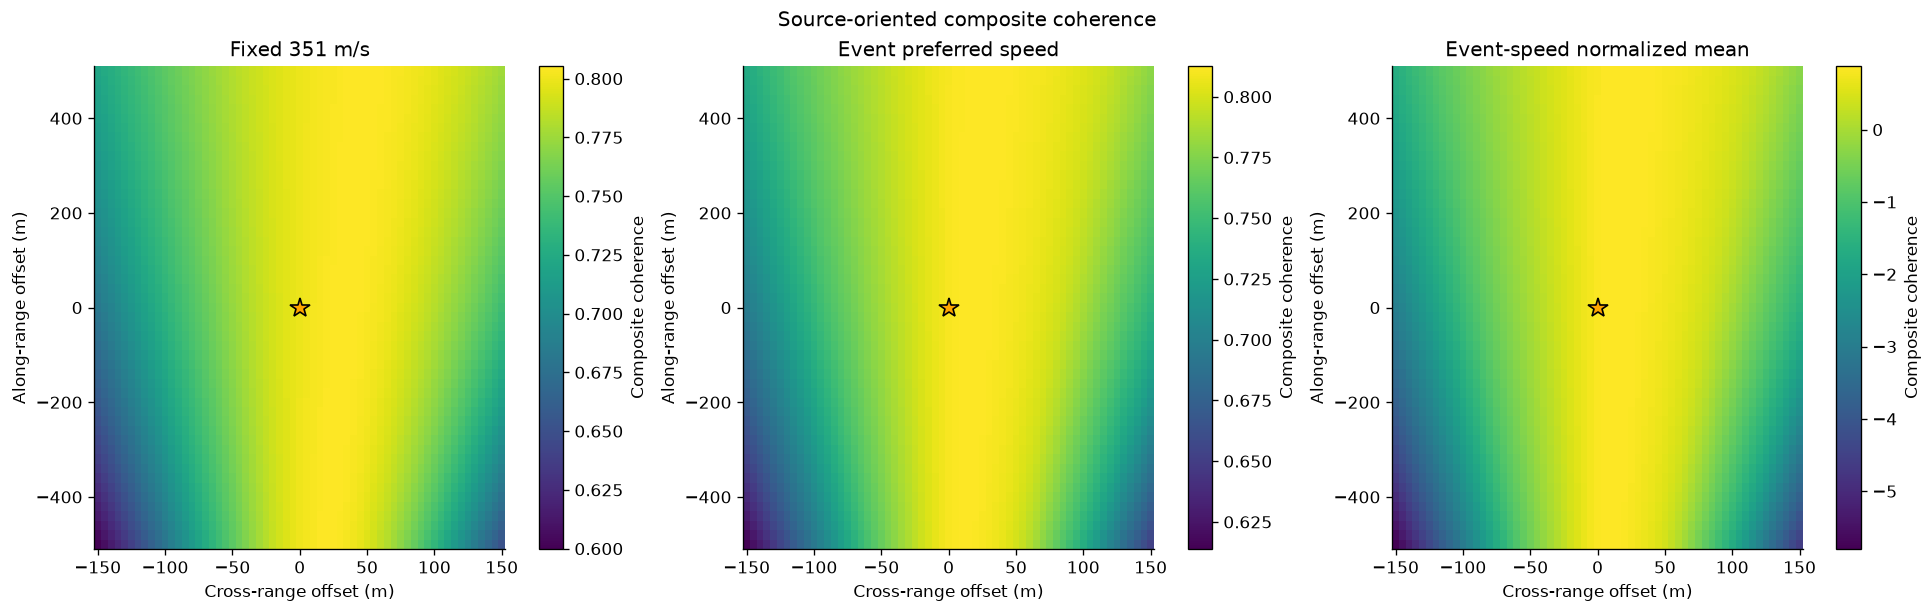

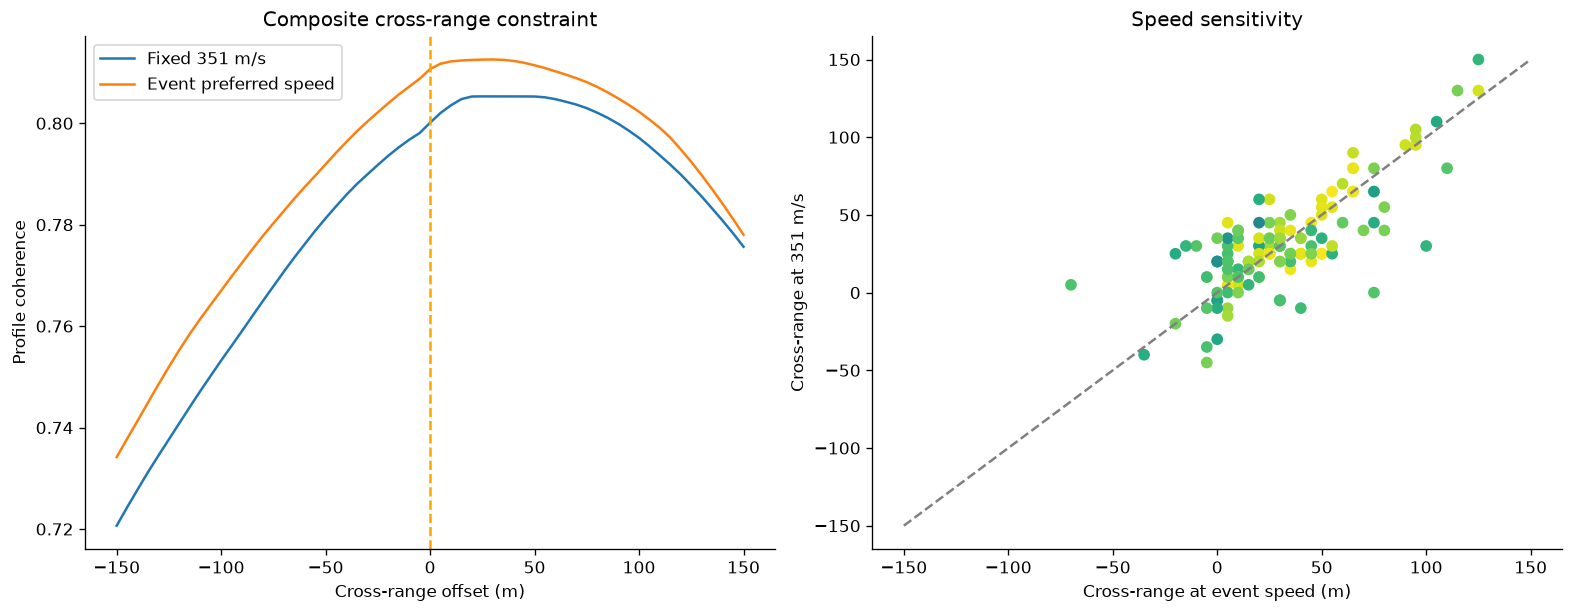

In [7]:
def plot_profile_event(event_number):
    fixed = fixed_results.loc[fixed_results["event_number"] == event_number].iloc[0]
    cached = event_cache[event_number]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    for ax, surface, title in [
        (axes[0], cached["profile_surface_351"], f"Fixed {LOCAL_GRID_SPEED_MPS:.0f} m s$^{{-1}}$"),
        (axes[1], cached["profile_surface_event_speed"], f"Event speed {fixed.fixed_source_speed_mps:.1f} m s$^{{-1}}$"),
    ]:
        mesh = ax.pcolormesh(cross_grid_m, along_grid_m, surface, shading="auto", cmap="viridis")
        ax.plot(0, 0, "*", color="orange", mec="black", ms=12, label="SLC-40")
        ax.set(xlabel="Cross-range offset (m)", ylabel="Along-range offset (m)", title=title)
        ax.legend(fontsize=7)
        fig.colorbar(mesh, ax=ax, label="Coherence")
    axes[2].plot(cross_grid_m, cached["profile_cross_351"], label="Fixed 351 m/s")
    axes[2].plot(cross_grid_m, cached["profile_cross_event_speed"], label="Event preferred speed")
    axes[2].set(xlabel="Cross-range offset (m)", ylabel="Profile coherence", title="Maximized over range")
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.2)
    fig.suptitle(f"Event {event_number:03d}: circular-wavefront range profiling")
    fig.savefig(FIGURE_DIR / f"event_{event_number:03d}_range_profile.png", bbox_inches="tight")
    plt.close(fig)


if MAKE_PROFILE_EVENT_FIGURES and not profile_results.empty:
    for event_number in profile_results["event_number"]:
        plot_profile_event(int(event_number))
    print("Range-profile event figures:", FIGURE_DIR)

if profile_event_speed_surfaces:
    stack_351 = np.stack(profile_fixed351_surfaces)
    stack_event = np.stack(profile_event_speed_surfaces)
    composite_351 = np.nanmean(stack_351, axis=0)
    composite_event = np.nanmean(stack_event, axis=0)
    normalized_event = []
    for surface in stack_event:
        baseline = np.nanmedian(surface)
        scale = np.nanmax(surface) - baseline
        normalized_event.append((surface - baseline) / scale if scale > 0 else np.zeros_like(surface))
    composite_normalized = np.nanmean(np.stack(normalized_event), axis=0)
    np.savez_compressed(
        COMPOSITE_DIR / "range_profile_composites.npz",
        along_range_m=along_grid_m, cross_range_m=cross_grid_m,
        fixed351_mean=composite_351, event_speed_mean=composite_event,
        event_speed_normalized_mean=composite_normalized,
    )
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    for ax, surface, title in zip(
        axes,
        (composite_351, composite_event, composite_normalized),
        ("Fixed 351 m/s", "Event preferred speed", "Event-speed normalized mean"),
    ):
        mesh = ax.pcolormesh(cross_grid_m, along_grid_m, surface, shading="auto", cmap="viridis")
        ax.plot(0, 0, "*", color="orange", mec="black", ms=12)
        ax.set(xlabel="Cross-range offset (m)", ylabel="Along-range offset (m)", title=title)
        fig.colorbar(mesh, ax=ax, label="Composite coherence")
    fig.suptitle("Source-oriented composite coherence")
    fig.savefig(COMPOSITE_DIR / "range_profile_composite_maps.png", bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    composite_cross_351 = np.nanmax(composite_351, axis=0)
    composite_cross_event = np.nanmax(composite_event, axis=0)
    axes[0].plot(cross_grid_m, composite_cross_351, label="Fixed 351 m/s")
    axes[0].plot(cross_grid_m, composite_cross_event, label="Event preferred speed")
    axes[0].axvline(0, color="orange", ls="--")
    axes[0].set(xlabel="Cross-range offset (m)", ylabel="Profile coherence", title="Composite cross-range constraint")
    axes[0].legend()
    axes[1].scatter(
        profile_results["event_speed_best_cross_range_m"],
        profile_results["fixed351_best_cross_range_m"],
        c=fixed_results["fixed_source_coherence_score"], cmap="viridis", vmin=0, vmax=1,
    )
    lim = CROSS_RANGE_HALF_WIDTH_M
    axes[1].plot([-lim, lim], [-lim, lim], "--", color="0.5")
    axes[1].set(xlabel="Cross-range at event speed (m)", ylabel="Cross-range at 351 m/s", title="Speed sensitivity")
    fig.savefig(COMPOSITE_DIR / "cross_range_profile_summary.png", bbox_inches="tight")
    plt.show()


## Event figures and the principal explosion

Each figure combines the fixed-source speed curve, fixed-speed local source map,
and waveforms aligned under the preferred circular model. Event 13 receives the
same broader scoring window inherited from Notebook 05.


In [8]:
def plot_event(event_number):
    fixed = fixed_results.loc[fixed_results["event_number"] == event_number].iloc[0]
    cached = event_cache[event_number]
    has_local = "best_local_source" in cached
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    axes[0].plot(speed_grid, cached["speed_surface"][:, 0], color="black")
    axes[0].axvline(fixed.fixed_source_speed_mps, color="tab:red", ls="--", label="Best exact-distance speed")
    axes[0].axvline(fixed.planar_speed_mps, color="tab:blue", ls=":", label="Planar speed")
    axes[0].axvline(LOCAL_GRID_SPEED_MPS, color="orange", ls="--", label="Local-grid fixed speed")
    axes[0].set(xlabel="Acoustic speed (m s$^{-1}$)", ylabel="Coherence score", title="Fixed SLC-40 source")
    axes[0].legend(fontsize=7)

    if has_local:
        surface = cached["fine_score"]
        east_offset = cached["fine_east"] - slc40_xyz[0]
        north_offset = cached["fine_north"] - slc40_xyz[1]
        mesh = axes[1].pcolormesh(east_offset, north_offset, surface, shading="auto", cmap="viridis")
        source = cached["best_local_source"]
        axes[1].plot(0, 0, marker="*", ms=12, color="orange", mec="black", label="SLC-40")
        axes[1].plot(source[0]-slc40_xyz[0], source[1]-slc40_xyz[1], marker="x", ms=9, color="white", mew=2, label="Best")
        axes[1].set_aspect("equal")
        axes[1].set(xlabel="East offset (m)", ylabel="North offset (m)", title=f"Local source, {LOCAL_GRID_SPEED_MPS:.0f} m s$^{{-1}}$")
        axes[1].legend(fontsize=7)
        fig.colorbar(mesh, ax=axes[1], label="Coherence")
        alignment_source = source
        alignment_speed = LOCAL_GRID_SPEED_MPS
    else:
        axes[1].axis("off")
        alignment_source = slc40_xyz
        alignment_speed = fixed.fixed_source_speed_mps

    times, aligned = aligned_waveforms(
        cached["stream"], cached["reference_epoch_s"],
        delays_for_source(alignment_source, alignment_speed), cached["score_window"],
    )
    for i, channel in enumerate(CHANNELS):
        values = aligned[i] - np.nanmedian(aligned[i])
        scale = np.nanmax(np.abs(values))
        axes[2].plot(times, values / scale + (2-i)*2.2, lw=0.9, label=channel)
    stack = np.nanmedian(aligned - np.nanmedian(aligned, axis=1, keepdims=True), axis=0)
    stack_scale = np.nanmax(np.abs(stack))
    axes[2].plot(times, stack / stack_scale - 2.2, color="black", lw=1.2, label="Median stack")
    axes[2].set(xlabel="Time relative to event reference (s)", ylabel="Normalized and offset", title="Best circular alignment")
    axes[2].legend(fontsize=7)

    fig.suptitle(f"Event {event_number:03d}: circular-wavefront analysis")
    fig.savefig(FIGURE_DIR / f"event_{event_number:03d}_circular_analysis.png", bbox_inches="tight")
    plt.close(fig)


if MAKE_EVENT_FIGURES:
    for event_number in fixed_results["event_number"]:
        plot_event(int(event_number))
    print("Event figures:", FIGURE_DIR)

principal = circular_results.loc[circular_results["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER]
if principal.empty:
    raise ValueError("Principal explosion is missing from circular analysis")
principal.to_csv(OUTPUT_ROOT / "principal_explosion_circular_result.csv", index=False)
display(principal.T)


,11
event_number,13
reference_time_epoch_s,1472735239.427134
reference_time_utc,2016-09-01 13:07:19.427133560+00:00
passes_core_filter,False
planar_back_azimuth_deg,200.2
...,...
event_speed_along_width_drop_0p02_m,1000.0
event_speed_along_lower_drop_0p02_m,-500.0
event_speed_along_upper_drop_0p02_m,500.0
event_speed_along_open_low_drop_0p02,True


## Composite source map and catalogue comparisons

The composite averages the broad fixed-speed source surfaces. It shows whether
coherence from many events concentrates near SLC-40 or forms an extended ridge.
Individual source offsets are also plotted through time, but their physical
interpretation must respect the surface widths and fixed-speed assumption.


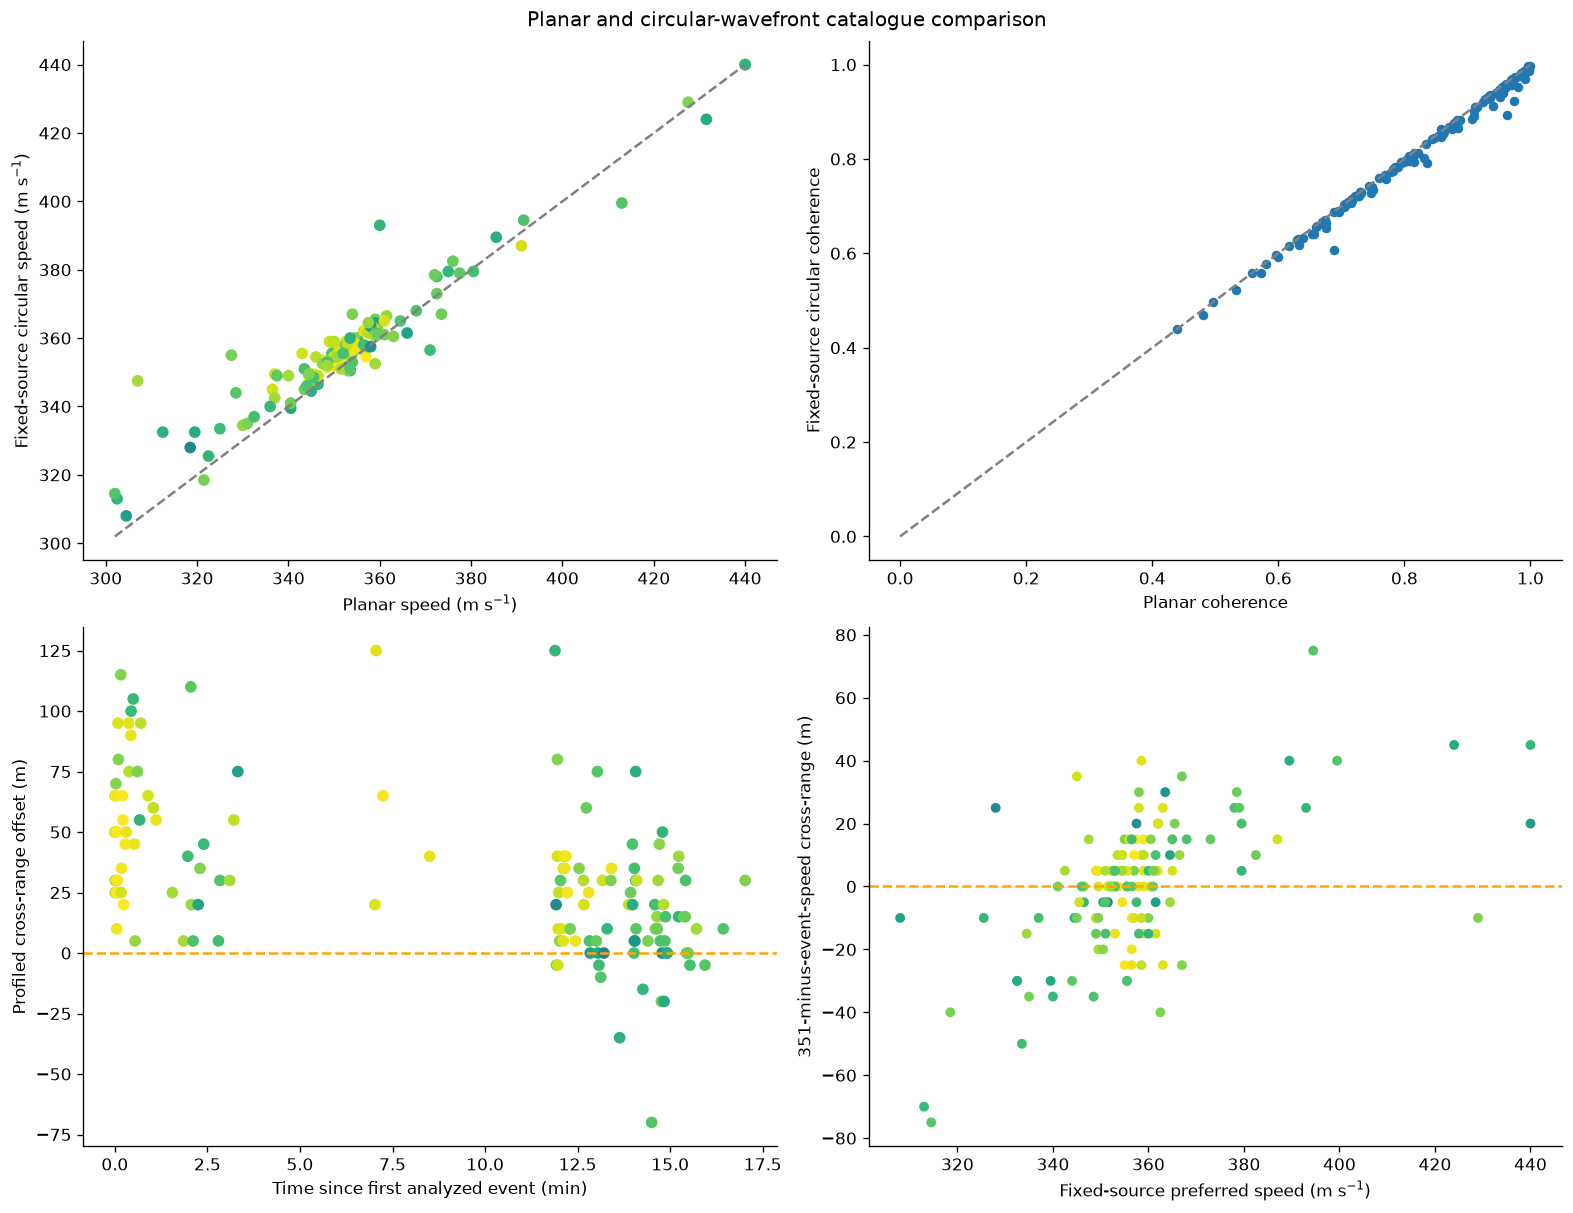

In [9]:
if coarse_composite_surfaces:
    stack = np.stack(coarse_composite_surfaces)
    normalized = []
    for surface in stack:
        baseline = np.nanmedian(surface)
        scale = np.nanmax(surface) - baseline
        normalized.append((surface - baseline) / scale if scale > 0 else np.zeros_like(surface))
    composites = {
        "mean": np.nanmean(stack, axis=0),
        "median": np.nanmedian(stack, axis=0),
        "normalized_mean": np.nanmean(np.stack(normalized), axis=0),
    }
    np.savez_compressed(COMPOSITE_DIR / "local_source_composites.npz",
                        east_offset_m=coarse_east_offsets, north_offset_m=coarse_north_offsets,
                        **composites)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    for ax, (name, surface) in zip(axes, composites.items()):
        mesh = ax.pcolormesh(coarse_east_offsets, coarse_north_offsets, surface, shading="auto", cmap="viridis")
        ax.plot(0, 0, "*", color="orange", mec="black", ms=13)
        ax.set_aspect("equal")
        ax.set(xlabel="East offset from SLC-40 (m)", ylabel="North offset (m)", title=name.replace("_", " ").title())
        fig.colorbar(mesh, ax=ax, label="Composite coherence")
    fig.suptitle(f"Composite local-source coherence at {LOCAL_GRID_SPEED_MPS:.0f} m s$^{{-1}}$")
    fig.savefig(COMPOSITE_DIR / "local_source_composite_maps.png", bbox_inches="tight")
    plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
axes[0,0].scatter(fixed_results["planar_speed_mps"], fixed_results["fixed_source_speed_mps"],
                  c=fixed_results["fixed_source_coherence_score"], cmap="viridis", vmin=0, vmax=1)
lo = min(fixed_results["planar_speed_mps"].min(), fixed_results["fixed_source_speed_mps"].min())
hi = max(fixed_results["planar_speed_mps"].max(), fixed_results["fixed_source_speed_mps"].max())
axes[0,0].plot([lo, hi], [lo, hi], "--", color="0.5")
axes[0,0].set(xlabel="Planar speed (m s$^{-1}$)", ylabel="Fixed-source circular speed (m s$^{-1}$)")

axes[0,1].scatter(fixed_results["planar_coherence_score"], fixed_results["fixed_source_coherence_score"], s=22)
axes[0,1].plot([0,1], [0,1], "--", color="0.5")
axes[0,1].set(xlabel="Planar coherence", ylabel="Fixed-source circular coherence")

if not profile_results.empty:
    merged = circular_results.sort_values("reference_time_epoch_s")
    elapsed_min = (merged["reference_time_epoch_s"] - merged["reference_time_epoch_s"].min()) / 60.0
    axes[1,0].scatter(elapsed_min, merged["event_speed_best_cross_range_m"], c=merged["event_speed_maximum_coherence"], cmap="viridis", vmin=0, vmax=1)
    axes[1,0].axhline(0, color="orange", ls="--")
    axes[1,0].set(xlabel="Time since first analyzed event (min)", ylabel="Profiled cross-range offset (m)")
    axes[1,1].scatter(merged["fixed_source_preferred_speed_mps"], merged["cross_range_speed_sensitivity_m"],
                      c=merged["event_speed_maximum_coherence"], cmap="viridis", vmin=0, vmax=1, s=24)
    axes[1,1].axhline(0, color="orange", ls="--")
    axes[1,1].set(xlabel="Fixed-source preferred speed (m s$^{-1}$)", ylabel="351-minus-event-speed cross-range (m)")

fig.suptitle("Planar and circular-wavefront catalogue comparison")
fig.savefig(OUTPUT_ROOT / "circular_planar_catalogue_summary.png", bbox_inches="tight")
plt.show()


## Summary and safeguards

- The fixed-source speed solution is the primary finite-distance result.
- The local-grid location assumes 351 m s⁻¹ and must not be presented as an
  independently resolved source coordinate.
- A maximum on a grid edge or a broad near-maximum region indicates poor
  constraint, even when the maximum coherence is high.
- The expected curvature delay across this ~30 m array at ~1.42 km range is of
  order 1 ms or less, so large planar–circular differences warrant scrutiny.
- Event 13 is retained even though its waveform is Friedlander-like rather than
  a simple positive–negative pulse.


In [10]:
summary = {
    "events_analyzed": int(len(fixed_results)),
    "median_planar_speed_mps": float(fixed_results["planar_speed_mps"].median()),
    "median_fixed_source_speed_mps": float(fixed_results["fixed_source_speed_mps"].median()),
    "median_fixed_minus_planar_coherence": float(fixed_results["fixed_minus_planar_coherence"].median()),
    "slc40_east_m": float(slc40_xyz[0]),
    "slc40_north_m": float(slc40_xyz[1]),
    "slc40_back_azimuth_deg": slc40_back_azimuth_deg,
    "slc40_range_m": slc40_range_m,
    "local_grid_speed_mps": LOCAL_GRID_SPEED_MPS,
    "geometry_model": "3-D spherical" if elevation_column else "2-D horizontal circular",
    "identifiability_warning": "Source east, source north, and speed are not jointly identifiable from three sensors using relative delays alone.",
}
if not local_results.empty:
    summary.update({
        "median_local_cross_range_offset_m": float(local_results["cross_range_offset_m"].median()),
        "median_local_along_range_offset_m": float(local_results["along_range_offset_m"].median()),
        "local_coarse_edge_events": int(local_results["coarse_best_on_edge"].sum()),
        "local_fine_edge_events": int(local_results["fine_best_on_edge"].sum()),
    })
if not profile_results.empty:
    summary.update({
        "median_profile_cross_range_event_speed_m": float(profile_results["event_speed_best_cross_range_m"].median()),
        "median_profile_cross_range_fixed351_m": float(profile_results["fixed351_best_cross_range_m"].median()),
        "median_cross_range_speed_sensitivity_m": float(profile_results["cross_range_speed_sensitivity_m"].median()),
        "event_speed_along_range_edge_events": int(profile_results["event_speed_best_on_along_edge"].sum()),
        "event_speed_cross_range_edge_events": int(profile_results["event_speed_best_on_cross_edge"].sum()),
        "event_speed_along_profile_open_events_drop_0p01": int((
            profile_results["event_speed_along_open_low_drop_0p01"]
            | profile_results["event_speed_along_open_high_drop_0p01"]
        ).sum()),
        "event_speed_cross_profile_open_events_drop_0p01": int((
            profile_results["event_speed_cross_open_low_drop_0p01"]
            | profile_results["event_speed_cross_open_high_drop_0p01"]
        ).sum()),
    })
(OUTPUT_ROOT / "circular_analysis_summary.json").write_text(json.dumps(summary, indent=2))
display(pd.Series(summary, name="value").to_frame())
print("Primary comparison:", OUTPUT_ROOT / "circular_planar_comparison.csv")


,value
events_analyzed,138
median_planar_speed_mps,352.5
median_fixed_source_speed_mps,355.5
median_fixed_minus_planar_coherence,-0.005093
slc40_east_m,541352.816861
slc40_north_m,3159526.382409
slc40_back_azimuth_deg,199.024952
slc40_range_m,1419.791492
local_grid_speed_mps,352.0
geometry_model,3-D spherical


Primary comparison: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/array_analysis_circular/circular_planar_comparison.csv
